# **Predicting Stroke Risk Using Patient Health and Lifestyle Data**

- Team **Predictra**
- Sabaragamuwa University of Sri Lanka
    - Sankajith D. Jinasena - sankajithdjinasena@gmail.com (Team Leader)
    - P.M. Sanodya V. Jinadasa
    - S. Nasmath Leena
    - T. Kugashanth

## **Import required libraries**

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#### **Matplotlib settings**

In [78]:
# Color palette
STROKE    = '#E63946'
NO_STROKE = '#457B9D'
ACCENT    = '#F4A261'
DARK      = '#1D3557'

plt.rcParams.update({
    'axes.grid'        : True,
    'grid.linewidth'   : 0.6,
    'font.family'      : 'Times New Roman',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'savefig.dpi'      : 150,
    'savefig.bbox'     : 'tight',
})

## **Load the dataset**

In [79]:
data = pd.read_csv("Data/healthcare_data.csv")
data.head()

,Unnamed: 0,patient_id,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk
0,1,30669,M,3.0,0,0,0,other,Rural,95.12,18.0,unknown,0,young,0,0,underweight,low
1,2,30468,M,58.0,1,0,1,working,Urban,87.96,39.2,non_smoker,0,middle,1,0,obese,low
2,3,16523,F,8.0,0,0,0,working,Urban,110.89,17.6,unknown,0,young,0,0,underweight,low
3,4,56543,F,70.0,0,0,1,working,Rural,69.04,35.9,ex_smoker,0,senior,0,0,obese,medium
4,5,46136,M,14.0,0,0,0,other,Rural,161.28,19.1,unknown,0,young,0,1,normal,low


In [80]:
data.shape

(9722, 18)

In [81]:
data.drop(columns=["Unnamed: 0","patient_id"], inplace=True)
data.head()

,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk
0,M,3.0,0,0,0,other,Rural,95.12,18.0,unknown,0,young,0,0,underweight,low
1,M,58.0,1,0,1,working,Urban,87.96,39.2,non_smoker,0,middle,1,0,obese,low
2,F,8.0,0,0,0,working,Urban,110.89,17.6,unknown,0,young,0,0,underweight,low
3,F,70.0,0,0,1,working,Rural,69.04,35.9,ex_smoker,0,senior,0,0,obese,medium
4,M,14.0,0,0,0,other,Rural,161.28,19.1,unknown,0,young,0,1,normal,low


In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9722 entries, 0 to 9721
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             9722 non-null   object 
 1   age                9722 non-null   float64
 2   has_hypertension   9722 non-null   int64  
 3   has_heart_disease  9722 non-null   int64  
 4   marital_status     9722 non-null   int64  
 5   employment_type    9722 non-null   object 
 6   residence          9722 non-null   object 
 7   glucose_level      9722 non-null   float64
 8   bmi_value          8795 non-null   float64
 9   smoking_habit      9722 non-null   object 
 10  stroke_event       9722 non-null   int64  
 11  age_group          9722 non-null   object 
 12  risk_score         9722 non-null   int64  
 13  high_glucose       9722 non-null   int64  
 14  bmi_category       9722 non-null   object 
 15  lifestyle_risk     9722 non-null   object 
dtypes: float64(3), int64(6),

In [83]:
data.describe()

,age,has_hypertension,has_heart_disease,marital_status,glucose_level,bmi_value,stroke_event,risk_score,high_glucose
count,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,8795.000000,9722.000000,9722.000000,9722.000000
mean,54.895943,0.182781,0.115717,0.762497,119.022954,29.594031,0.500000,0.298498,0.267023
std,22.316333,0.386507,0.319902,0.425575,55.540275,7.278338,0.500026,0.526214,0.442427
min,0.080000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,0.000000,1.000000,78.265000,24.800000,0.000000,0.000000,0.000000
50%,59.000000,0.000000,0.000000,1.000000,96.760000,28.600000,0.500000,0.000000,0.000000
75%,75.000000,0.000000,0.000000,1.000000,151.160000,33.400000,1.000000,1.000000,1.000000
max,82.000000,1.000000,1.000000,1.000000,271.740000,97.600000,1.000000,2.000000,1.000000


In [84]:
data["gender"].value_counts()

gender
F    5627
M    4095
Name: count, dtype: int64

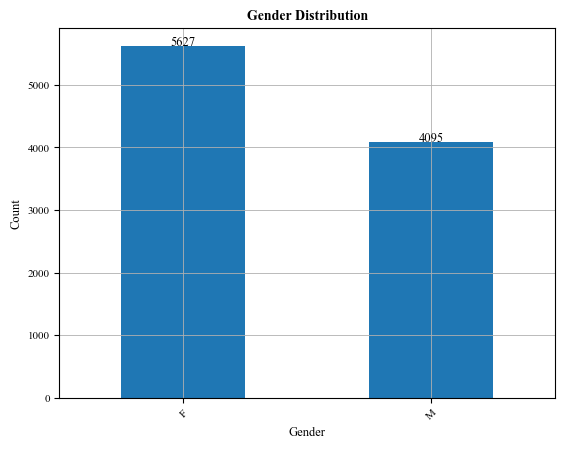

In [85]:
ax = data["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=45)

for i, v in enumerate(data["gender"].value_counts()):
    ax.text(i, v + 0.5, str(v), ha='center')
plt.savefig("Figures/Gender_Distribution.png")
plt.show()

In [86]:
data['employment_type'].value_counts()

employment_type
working       7693
government    1278
other          751
Name: count, dtype: int64

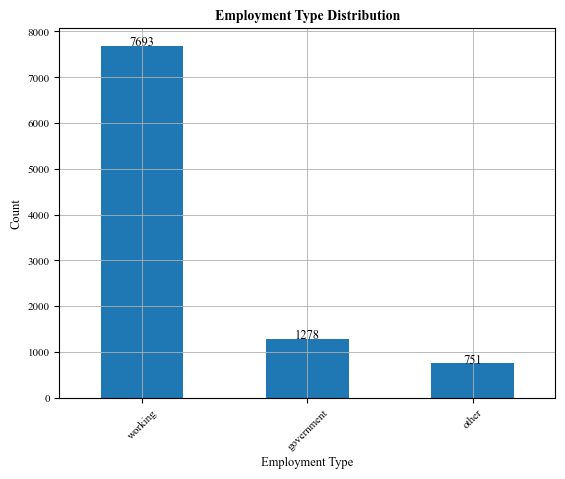

In [87]:
ax = data["employment_type"].value_counts().plot(kind="bar")

plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

for i, v in enumerate(data["employment_type"].value_counts()):
    ax.text(i, v + 0.5, str(v), ha='center')

plt.savefig("Figures/Employment_Type_Distribution.png")

plt.show()

In [88]:
data["residence"].value_counts()

residence
Urban    5107
Rural    4615
Name: count, dtype: int64

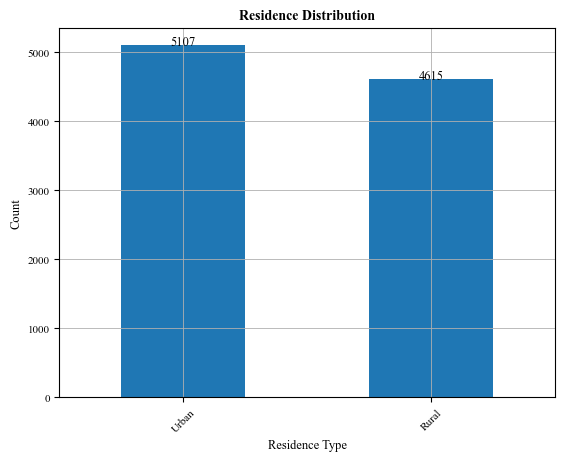

In [89]:
ax = data["residence"].value_counts().plot(kind="bar")

plt.title("Residence Distribution")
plt.xlabel("Residence Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

for i, v in enumerate(data["residence"].value_counts()):
    ax.text(i, v + 0.5, str(v), ha='center')

plt.savefig("Figures/Residence_Distribution.png")

plt.show()

In [90]:
data["smoking_habit"].value_counts()

smoking_habit
non_smoker        3560
unknown           2395
ex_smoker         2179
current_smoker    1588
Name: count, dtype: int64

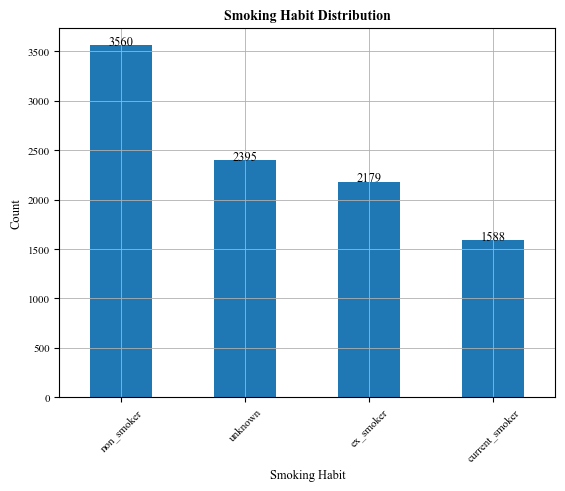

In [91]:
ax = data["smoking_habit"].value_counts().plot(kind="bar")

plt.title("Smoking Habit Distribution")
plt.xlabel("Smoking Habit")
plt.ylabel("Count")
plt.xticks(rotation=45)

for i, v in enumerate(data["smoking_habit"].value_counts()):
    ax.text(i, v + 0.5, str(v), ha='center')

plt.savefig("Figures/Smoking_Habit_Distribution.png")

plt.show()

In [92]:
data['bmi_value'] = data.groupby('bmi_category')['bmi_value'].transform(lambda x: x.fillna(x.median()))

In [93]:
data['age_bmi']     = data['age'] * data['bmi_value']
data['glucose_age'] = data['glucose_level'] * data['age']
data['comorbidity'] = data['has_hypertension'] + data['has_heart_disease']

In [94]:
data.head()

,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk,age_bmi,glucose_age,comorbidity
0,M,3.0,0,0,0,other,Rural,95.12,18.0,unknown,0,young,0,0,underweight,low,54.0,285.36,0
1,M,58.0,1,0,1,working,Urban,87.96,39.2,non_smoker,0,middle,1,0,obese,low,2273.6,5101.68,1
2,F,8.0,0,0,0,working,Urban,110.89,17.6,unknown,0,young,0,0,underweight,low,140.8,887.12,0
3,F,70.0,0,0,1,working,Rural,69.04,35.9,ex_smoker,0,senior,0,0,obese,medium,2513.0,4832.80,0
4,M,14.0,0,0,0,other,Rural,161.28,19.1,unknown,0,young,0,1,normal,low,267.4,2257.92,0


In [95]:
data.describe()

,age,has_hypertension,has_heart_disease,marital_status,glucose_level,bmi_value,stroke_event,risk_score,high_glucose,age_bmi,glucose_age,comorbidity
count,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000
mean,54.895943,0.182781,0.115717,0.762497,119.022954,30.052283,0.500000,0.298498,0.267023,1683.234591,6867.326010,0.298498
std,22.316333,0.386507,0.319902,0.425575,55.540275,7.065063,0.500026,0.526214,0.442427,760.094934,4791.996976,0.526214
min,0.080000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000,0.000000,1.128000,5.626400,0.000000
25%,41.000000,0.000000,0.000000,1.000000,78.265000,25.400000,0.000000,0.000000,0.000000,1212.000000,3503.505000,0.000000
50%,59.000000,0.000000,0.000000,1.000000,96.760000,29.700000,0.500000,0.000000,0.000000,1813.050000,5515.200000,0.000000
75%,75.000000,0.000000,0.000000,1.000000,151.160000,34.400000,1.000000,1.000000,1.000000,2227.800000,9066.830000,1.000000
max,82.000000,1.000000,1.000000,1.000000,271.740000,97.600000,1.000000,2.000000,1.000000,4040.400000,20770.400000,2.000000


## **Exploratory Data Analysis**

### **Categorical Variable Distributions**


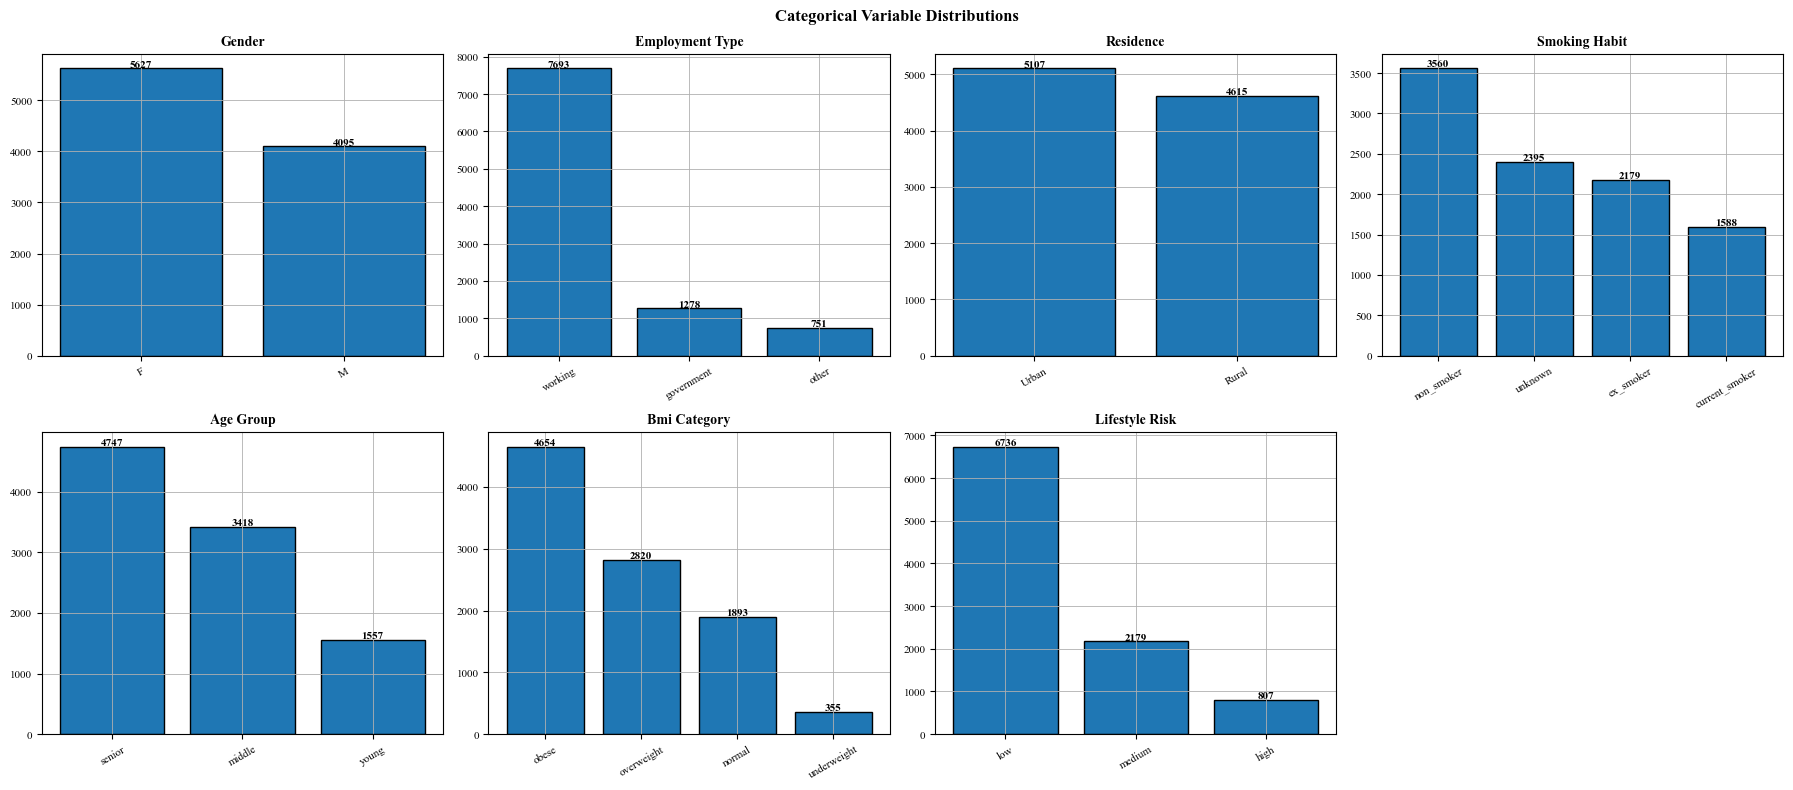

In [96]:
categorical_cols = ['gender', 'employment_type', 'residence', 'smoking_habit', 'age_group', 'bmi_category', 'lifestyle_risk']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Categorical Variable Distributions', fontsize=12,
             fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = data[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       edgecolor='black')
    for b, v in zip(bars, counts.values):
        axes[i].text(b.get_x() + b.get_width()/2, v + 20, str(v),
                     ha='center', fontsize=8, fontweight='bold')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("Figures/Categorical_Variable_Distribution.png")
plt.show()

### **Numerical Variable Distributions**

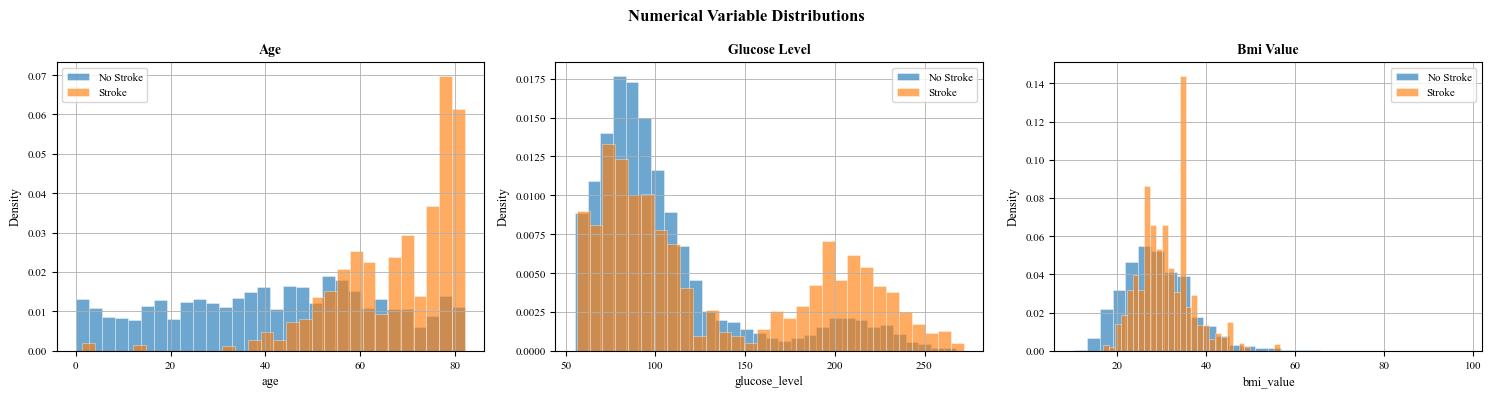

In [97]:
numerical_cols = ['age', 'glucose_level', 'bmi_value']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Numerical Variable Distributions', fontsize=12,
             fontweight='bold')

for ax, col in zip(axes, numerical_cols):
    for val, lbl in [(0,  'No Stroke'), (1, 'Stroke')]:
        ax.hist(data[data['stroke_event'] == val][col].dropna(),
                bins=30, alpha=0.65, label=lbl,
                density=True, edgecolor='white', linewidth=0.4)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig("Figures/Numerical_Variable_Distribution.png")
plt.show()

### **Demographic & Clinical Overview**

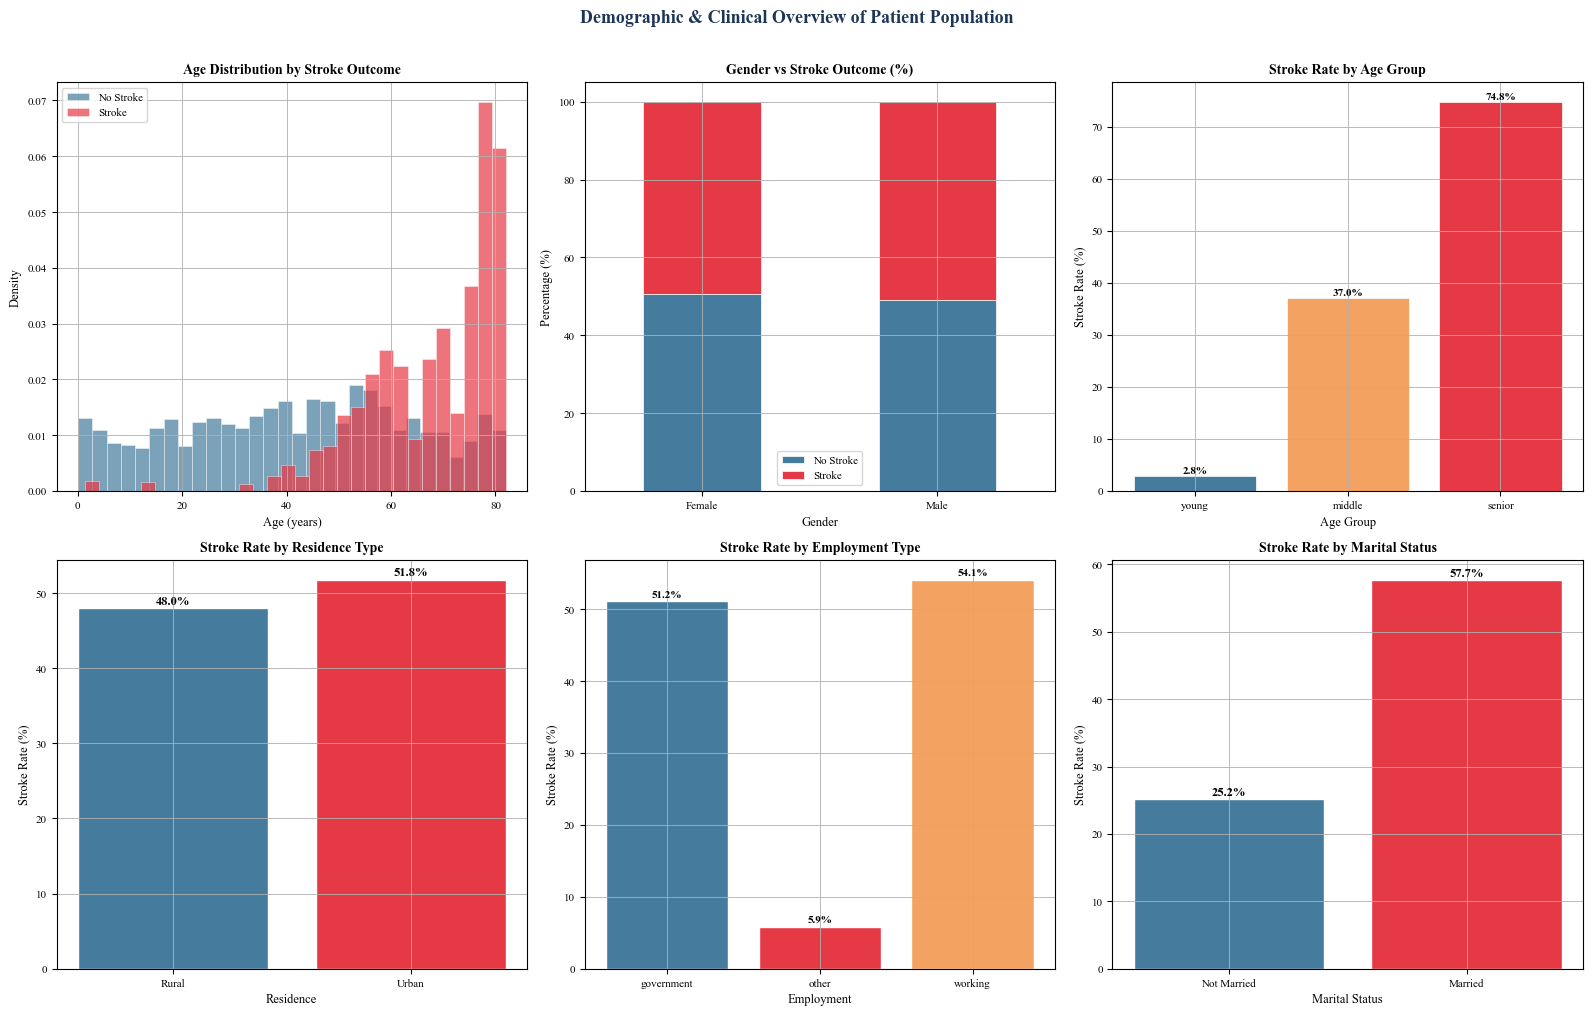

In [98]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Demographic & Clinical Overview of Patient Population',
             fontsize=13, fontweight='bold', color=DARK, y=1.01)
axes = axes.flatten()

# Age distribution by stroke
for value, color, label in [(0, NO_STROKE, 'No Stroke'), (1, STROKE, 'Stroke')]:
    axes[0].hist(data[data['stroke_event'] == value]['age'], bins=30, alpha=0.7,  color=color, label=label, density=True, edgecolor='white', linewidth=0.4)
axes[0].set(title='Age Distribution by Stroke Outcome', xlabel='Age (years)', ylabel='Density')
axes[0].legend()

# Gender vs Stroke stacked bar
gdf = data.groupby(['gender', 'stroke_event']).size().unstack(fill_value=0)
gdf_pct = gdf.div(gdf.sum(axis=1), axis=0) * 100
gdf_pct.plot(kind='bar', stacked=True, ax=axes[1], color=[NO_STROKE, STROKE], edgecolor='white', linewidth=0.5)
axes[1].set(title='Gender vs Stroke Outcome (%)', xlabel='Gender', ylabel='Percentage (%)')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend(['No Stroke', 'Stroke'])

# Age group stroke rate
ag_rate = data.groupby('age_group')['stroke_event'].mean() * 100
order = ['young', 'middle', 'senior']
bars = axes[2].bar(order, [ag_rate[o] for o in order], color=[NO_STROKE, ACCENT, STROKE], edgecolor='white', linewidth=0.5)
for b, v in zip(bars, [ag_rate[o] for o in order]):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[2].set(title='Stroke Rate by Age Group', xlabel='Age Group', ylabel='Stroke Rate (%)')

# Residence vs Stroke stacked
res_rate = data.groupby('residence')['stroke_event'].mean() * 100
bars2 = axes[3].bar(res_rate.index, res_rate.values, color=[NO_STROKE, STROKE], edgecolor='white')
for b, v in zip(bars2, res_rate.values):
    axes[3].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[3].set(title='Stroke Rate by Residence Type', xlabel='Residence', ylabel='Stroke Rate (%)')

# Employment type vs Stroke stacked
emp_rate = data.groupby('employment_type')['stroke_event'].mean() * 100
bars3 = axes[4].bar(emp_rate.index, emp_rate.values, color=[NO_STROKE, STROKE, ACCENT], edgecolor='white')
for b, v in zip(bars3, emp_rate.values):
    axes[4].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[4].set(title='Stroke Rate by Employment Type', xlabel='Employment', ylabel='Stroke Rate (%)')

# Marital status
mar = data.groupby('marital_status')['stroke_event'].mean() * 100
bars4 = axes[5].bar(['Not Married', 'Married'], mar.values, color=[NO_STROKE, STROKE], edgecolor='white')
for b, v in zip(bars4, mar.values):
    axes[5].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[5].set(title='Stroke Rate by Marital Status', xlabel='Marital Status', ylabel='Stroke Rate (%)')

plt.tight_layout()
plt.savefig("Figures/Demographic_&_Clinical_Overview_of_Patient_Population.png")
plt.show()


### **Clinical Measurements & Biomarker Analysis**